In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [29]:
df=pd.read_csv("C:\\Users\\LENOVO\\Downloads\\placement.csv")

In [30]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [31]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [32]:
df.shape

(100, 4)

In [33]:
df.isnull().sum()

Unnamed: 0    0
cgpa          0
iq            0
placement     0
dtype: int64

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23024\2890220447.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


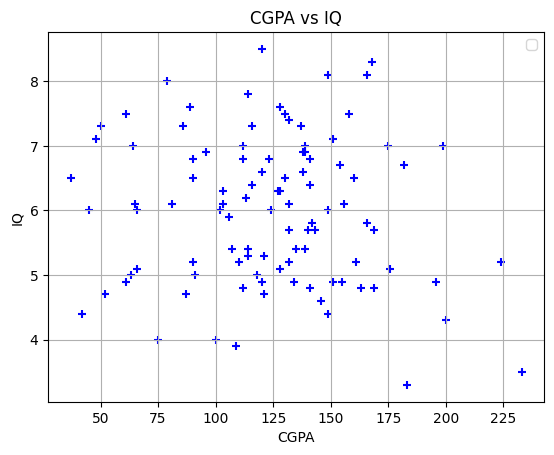

In [35]:
plt.scatter(df['iq'],df['cgpa'],color='blue',marker='+')
plt.title('CGPA vs IQ')
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.legend()
plt.grid()
plt.show()

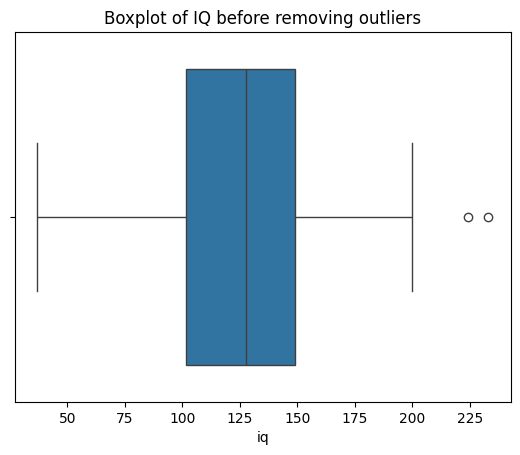

In [36]:
sns.boxplot(x='iq',data=df)
plt.title('Boxplot of IQ before removing outliers')
plt.show()

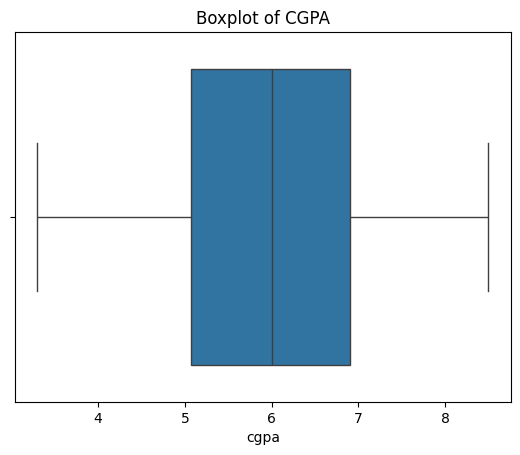

In [37]:
sns.boxplot(x='cgpa',data=df)
plt.title('Boxplot of CGPA')
plt.show()

In [38]:
iqr=df['iq'].quantile(0.75)-df['iq'].quantile(0.25)
lower_bound=df['iq'].quantile(0.25)-(1.5*iqr)
upper_bound=df['iq'].quantile(0.75)+(1.5*iqr)
outliers=df[(df['iq']<lower_bound) | (df['iq']>upper_bound)]
print("Outliers in IQ:\n",outliers)


Outliers in IQ:
     Unnamed: 0  cgpa     iq  placement
16          16   5.2  224.0          0
50          50   3.5  233.0          0


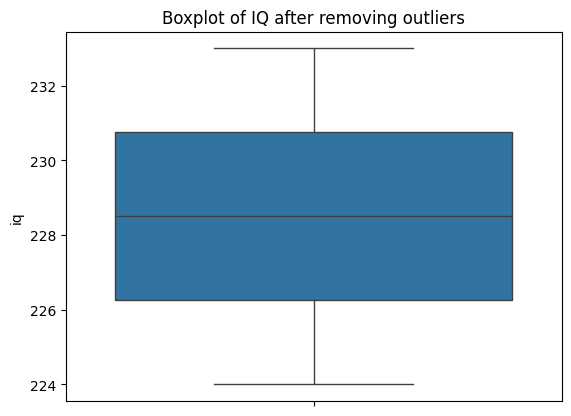

In [39]:
sns.boxplot(outliers['iq'])
plt.title('Boxplot of IQ after removing outliers')
plt.show()

In [40]:
X=df[['cgpa']]
y=df[['iq']]

In [41]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred=lr.predict(X_test)

In [48]:
y_pred_1d = y_pred.flatten()
compare_df=pd.DataFrame({'Actual':y_test.values.flatten(),'Predicted':y_pred_1d})
print(compare_df)

    Actual   Predicted
0    130.0  120.781113
1    168.0  118.168457
2    127.0  124.700096
3     66.0  125.679842
4     61.0  120.781113
5    146.0  130.251989
6    120.0  129.272243
7    196.0  129.272243
8     45.0  125.679842
9    123.0  123.067186
10   100.0  132.211481
11   128.0  120.454531
12    61.0  129.272243
13   149.0  125.679842
14    86.0  121.434277
15   142.0  126.333006
16   155.0  129.272243
17    50.0  121.434277
18   139.0  127.639333
19   109.0  132.538063


In [49]:
print("\nModel Evaluation:")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")



Model Evaluation:
R2 Score: -0.05
Mean Absolute Error: 33.39
Mean Squared Error: 1762.65
Root Mean Squared Error: 41.98


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


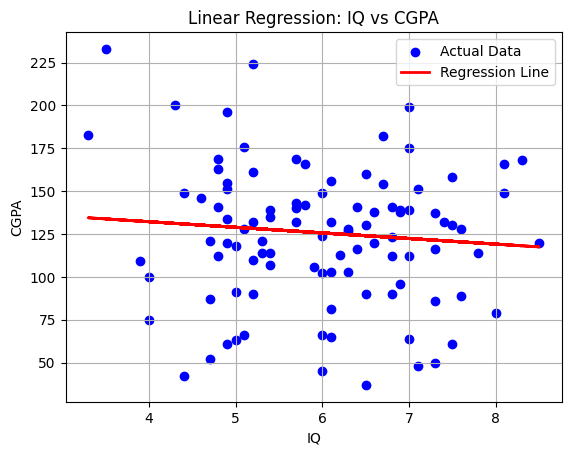

In [50]:



plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, lr.predict(X.values.reshape(-1,1)), color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: IQ vs CGPA')
plt.xlabel('IQ')
plt.ylabel('CGPA')
plt.legend()
plt.grid()
plt.show()